In [4]:
from scipy.stats import sem
import matplotlib.pyplot as plt
import seaborn as sns
from my_fun.my_fun import fig_size, save_notebook_files
from analysis import *
from ephys.decoder import get_selectivity, plot_weights_dist

In [5]:
# Magics
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# Plotting style
sns.set_theme(style='ticks', context='notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

# Load example session

In [7]:
# Example session
subject = '007'
ephys_id = '007_2024-06-24_17-47-22'
preprocessed = preprocess(ephys_id)
cluster_info = preprocessed.cluster_info
df_spikes = preprocessed.df_spikes
df_ttl = preprocessed.df_ttl
df_behavior = preprocessed.df_behavior

align = 'stim'
folder_parent = Path.home() / 'data' / subject
folder_child = folder_parent / ephys_id
bins = np.load(folder_child / f'bins_{align}.npy')
all_psth = np.load(folder_child / f'all_psth_{align}.npy')

# Load GLM-HMM fit
path_glmhmm = ((Path.home() / 'PycharmProjects' / 'glmhmm' / 'TEST' / '2s_3cov' / 'Ephys' / subject)
               .with_suffix('.csv'))  # Fitted sphys sessions only
df_glmhmm = pd.read_csv(path_glmhmm)  # All sessions concatenated
session = df_behavior.Session.unique()[0]
df_glmhmm = df_glmhmm[df_glmhmm.Session == session].reset_index(drop=True)

# Drop misses (GLM-HMM lack misses)
resp_idx = df_behavior[df_behavior.Miss == 0].index
df_behavior = df_behavior.iloc[resp_idx].reset_index(drop=True)
all_psth = all_psth[resp_idx]
df_ttl = df_ttl.iloc[resp_idx].reset_index(drop=True)
assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
df_behavior = df_glmhmm
print(f'Len original df: {len(df_behavior)}')

# Drop disengaged trials
eng_idx = df_behavior.index[df_behavior['State'] == 1].to_numpy()
df_behavior = df_behavior.loc[eng_idx].reset_index(drop=True)
all_psth = all_psth[eng_idx, :, :]
df_ttl = df_ttl.iloc[eng_idx].reset_index(drop=True)

df_behavior['Trial'] = np.arange(len(df_behavior))  # Otherwise peri_event_spikes won't work
print(f'N = {len(df_behavior)} engaged trials')

Development mode: remote (minibaps, alexis, Linux)

Processor ID: 109, Stream Name: ProbeA-AP, Line: 1 (main sync line))
  First event sample number: 59449398
  Last event sample number: 230358711
  Total sync events: 6000
  Sample rate: 30000.0
Processor ID: 109, Stream Name: ProbeA-LFP, Line: 1 (aux sync line))
  First event sample number: 4954116
  Last event sample number: 19196559
  Total sync events: 4763
  Scale factor: 11.99999978936198
  Actual sample rate: 2500.0000438829215


Development mode: remote (minibaps, alexis, Linux)

All sounds sent by Bpod match those received by Arduino
There is(are) 1 more ephys trial(s) than behavior trial(s)
999 trials common to both data sources. Using it for later slicing
All sounds from behavior and ephys match


Min spike time: 0 min
Max spike time: 126 min


The aquisition (press PLAY in Open Ephys) started at 0 min and ended after 144 min. It includes the time for lowering the probe.
The recording (press REC in Open Ephys) started at 18 

# Filter data

## Fano factor

In [7]:
def get_fano_subject(subject, align='stim'):
    """
    Compute Fano factors for all sessions of a subject.
    :param subject: Subject ID (str)
    :param align: Alignment event ('stim' or 'resp')
    """

    folder_parent = Path.home() / 'data' / subject
    ephys_ids = get_ephys_sessions(subject)
    error_sessions = []
    fano_subject = []

    for i, session_id in enumerate(ephys_ids):
        folder_child = folder_parent / session_id
        try:
            print(f'Processing session {i + 1}/{len(ephys_ids)}: {session_id}...')
            all_psth = np.load(folder_child / f'all_psth_{align}.npy')
            fano_session = get_session_fano(all_psth)
            # fano_subject.extend(fano_session)  # Append all neurons into one flat list
            fano_subject.append(fano_session)  # Append all neurons into one flat list

        except Exception as e:
            print(f'An error occurred in session {session_id}: {e}')
            error_sessions.append(session_id)
            continue

    return fano_subject


def plot_mean_fano_dist(all_fano):
    """
    Compute session-wise Fano factor distributions, then plot the mean histogram across sessions.
    :param all_fano: List of lists, where each inner list contains Fano factors for all neurons in a session.
    """

    max_fano = 30
    bins = np.linspace(0, max_fano, 100)  # adjust as needed
    session_histograms = []
    for session in all_fano:
        counts, _ = np.histogram(session, bins=bins, density=True)
        session_histograms.append(counts)
    session_histograms = np.array(session_histograms)
    mean_hist = session_histograms.mean(axis=0)
    sem_hist = sem(session_histograms, axis=0)

    # Plot mean histogram
    bin_centers = (bins[:-1] + bins[1:]) / 2
    plt.plot(bin_centers, mean_hist, color='k')
    band = (mean_hist - sem_hist, mean_hist + sem_hist)
    plt.fill_between(bin_centers, band[0], band[1], color='k', edgecolor='none', alpha=0.25)
    plt.xlim(0, max_fano)
    plt.ylim(0, None)
    plt.xlabel('Fano factor')
    plt.ylabel('Density')
    sns.despine()

Development mode: remote (minibaps, alexis, Linux)

['001_2024-05-24_23-09-23', '001_2024-05-25_16-34-53', '001_2024-05-28_14-42-25'] 

Processing session 1/3: 001_2024-05-24_23-09-23...
Processing session 2/3: 001_2024-05-25_16-34-53...
Processing session 3/3: 001_2024-05-28_14-42-25...
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15-54-23', '007_2024-06-26_15-19-30', '007_2024-06-27_15-06-28', '007_2024-06-28_14-18-51', '007_2024-06-29_16-24-52', '007_2024-07-06_11-16-25', '007_2024-07-07_13-20-29', '007_2024-07-08_12-20-29', '007_2024-07-09_12-10-57', '007_2024-07-10_12-03-35', '007_2024-07-11_12-39-21', '007_2024-07-12_13-29-26'] 

Processing session 1/15: 007_2024-06-22_10-48-57...
Processing session 2/15: 007_2024-06-23_12-46-55...
Processing session 3/15: 007_2024-06-24_17-47-22...
Processing session 4/15: 007_2024-06-25_15-54-23...
Processing session 5/15: 007_2024-06-26_15-

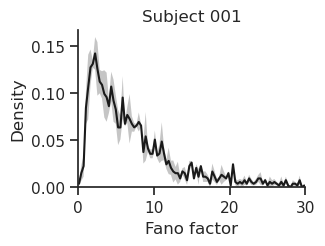

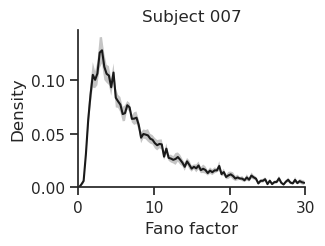

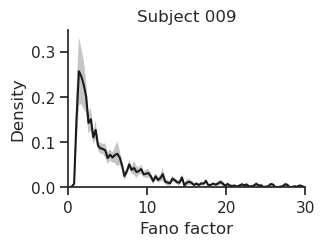

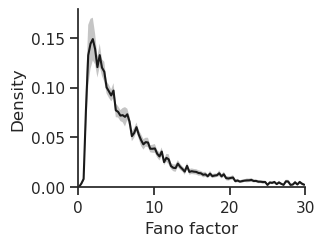

In [8]:
# Mean Fano factor distribution across sessions
figsize = fig_size(n_cols=2)
subjects = ['001', '007', '009']
all_fano = []
for s in subjects:
    fano_subject = get_fano_subject(s)
    all_fano.extend(fano_subject)
    plt.figure(figsize=figsize, constrained_layout=True)
    plot_mean_fano_dist(fano_subject)
    plt.title(f'Subject {s}')
plt.figure(figsize=figsize, constrained_layout=True)
plot_mean_fano_dist(all_fano)

## M2 vs sub M2

In [9]:
def get_cluster_info_subject(subject):
    """
    Compute Fano factors for all sessions of a subject.
    :param subject: Subject ID (str)
    """

    folder_parent = Path('/archive/mouse/Alexis ephys/spike_sorting') / subject
    ephys_ids = get_ephys_sessions(subject)

    error_sessions = []
    df = pd.DataFrame()

    for i, session_id in enumerate(ephys_ids):
        folder_child = folder_parent / session_id / 'phy2'
        try:
            print(f'Processing session {i + 1}/{len(ephys_ids)}: {session_id}...')
            cluster_info = pd.read_csv(folder_child / 'cluster_info.tsv', sep='\t')
            cluster_info['subject'] = subject
            cluster_info['session'] = session_id
            df = pd.concat([df, cluster_info], ignore_index=True)

        except Exception as e:
            print(f'An error occurred in session {session_id}: {e}')
            error_sessions.append(session_id)
            continue

    return df


def plot_mean_depth_dist(all_cluster_info, n_bins=100, max_depth=4):
    """
    Compute session-wise depth distributions (all neurons), then plot the mean histogram across sessions.
    :param all_cluster_info: DataFrame containing cluster information for all sessions, including 'session' and 'depth' columns.
    :param n_bins: Number of bins for the histogram.
    :param max_depth: Maximum depth to consider for the histogram (in mm).
    """

    sessions = all_cluster_info['session'].unique()
    bins = np.linspace(0, max_depth, n_bins)

    hist = []
    for session in sessions:
        session_data = all_cluster_info[all_cluster_info['session'] == session]
        surface = session_data.depth.max()
        session_data['depth_inverted'] = surface - session_data['depth']
        h, _ = np.histogram(session_data['depth_inverted'], bins=bins, density=True)
        hist.append(h)
    mean_hist = np.mean(hist, axis=0)
    sem_hist = sem(hist, axis=0)

    # Plot
    bin_centers = (bins[:-1] + bins[1:]) / 2
    plt.plot(bin_centers, mean_hist, color='k')
    band = (mean_hist - sem_hist, mean_hist + sem_hist)
    plt.fill_between(bin_centers, band[0], band[1], color='k', edgecolor='none', alpha=0.25)
    plt.xlim(0, max_depth)
    plt.ylim(0, None)
    plt.xlabel('Depth (mm)')
    plt.ylabel('Density')
    plt.legend(frameon=False)
    sns.despine()

Development mode: remote (minibaps, alexis, Linux)

['001_2024-05-24_23-09-23', '001_2024-05-25_16-34-53', '001_2024-05-28_14-42-25'] 

Processing session 1/3: 001_2024-05-24_23-09-23...
Processing session 2/3: 001_2024-05-25_16-34-53...
Processing session 3/3: 001_2024-05-28_14-42-25...
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15-54-23', '007_2024-06-26_15-19-30', '007_2024-06-27_15-06-28', '007_2024-06-28_14-18-51', '007_2024-06-29_16-24-52', '007_2024-07-06_11-16-25', '007_2024-07-07_13-20-29', '007_2024-07-08_12-20-29', '007_2024-07-09_12-10-57', '007_2024-07-10_12-03-35', '007_2024-07-11_12-39-21', '007_2024-07-12_13-29-26'] 

Processing session 1/15: 007_2024-06-22_10-48-57...
Processing session 2/15: 007_2024-06-23_12-46-55...
Processing session 3/15: 007_2024-06-24_17-47-22...
Processing session 4/15: 007_2024-06-25_15-54-23...
Processing session 5/15: 007_2024-06-26_15-

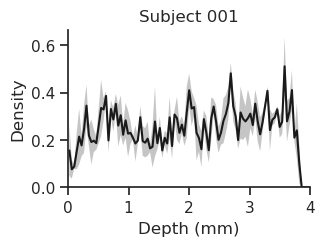

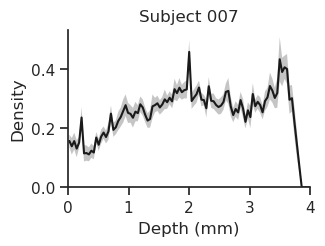

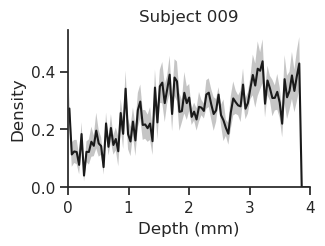

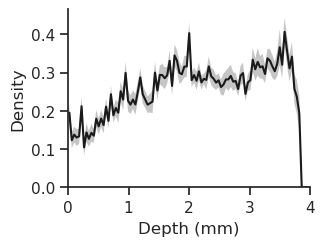

In [10]:
# Mean cluster density per depth distribution across sessions
subjects = ['001', '007', '009']
all_cluster_info = pd.DataFrame()
for s in subjects:
    df_cluster_info_subject = get_cluster_info_subject(s)
    df_cluster_info_subject['depth'] = df_cluster_info_subject['depth'] / 1000  # Convert to mm
    all_cluster_info = pd.concat([all_cluster_info, df_cluster_info_subject], ignore_index=True)
    plt.figure(figsize=fig_size(n_cols=2), constrained_layout=True)
    plot_mean_depth_dist(df_cluster_info_subject)
    plt.title(f'Subject {s}')
plt.figure(figsize=fig_size(n_cols=2), constrained_layout=True)
plot_mean_depth_dist(all_cluster_info)

Text(0.5, 1.0, 'All clusters')

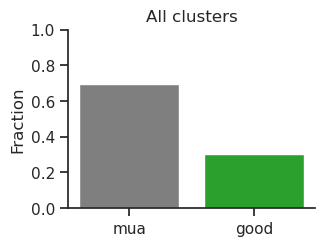

In [11]:
# Count clusters per group
all_cluster_info = all_cluster_info[all_cluster_info['group'].isin(['good', 'mua'])]
counts = all_cluster_info['group'].value_counts()
fractions = counts / counts.sum()

# Bar plot
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plt.bar(fractions.index, fractions.values, color=['tab:gray', 'tab:green'])
plt.ylim(0, 1)
plt.ylabel('Fraction')
sns.despine()
plt.title('All clusters')

# Plot example units

In [13]:
# # Example session
# subject = '007'
# ephys_id = '007_2024-06-24_17-47-22'
# preprocessed = preprocess(ephys_id)
# cluster_info = preprocessed.cluster_info
# df_spikes = preprocessed.df_spikes
# df_ttl = preprocessed.df_ttl
# df_behavior = preprocessed.df_behavior

Development mode: remote (minibaps, alexis, Linux)

'Plot 1: accuracy per side' took 0.17 seconds to run
'Plot 2: accuracy repeating vs alternating' took 0.1 seconds to run
'Plot 3: misses' took 0.15 seconds to run
'Plot 4: Hit scatter' took 0.06 seconds to run
'Saving 1st page in pdf' took 0.34 seconds to run
'Plot 5: peristimulus lick raster' took 5.58 seconds to run
'Plot 6: peristimulus lick histogram (all licks)' took 0.17 seconds to run
'Plot 8: peristimulus lick histogram (first licks)' took 0.13 seconds to run
'Saving 2nd page in pdf' took 2.59 seconds to run
The script took 17.92 seconds to run 



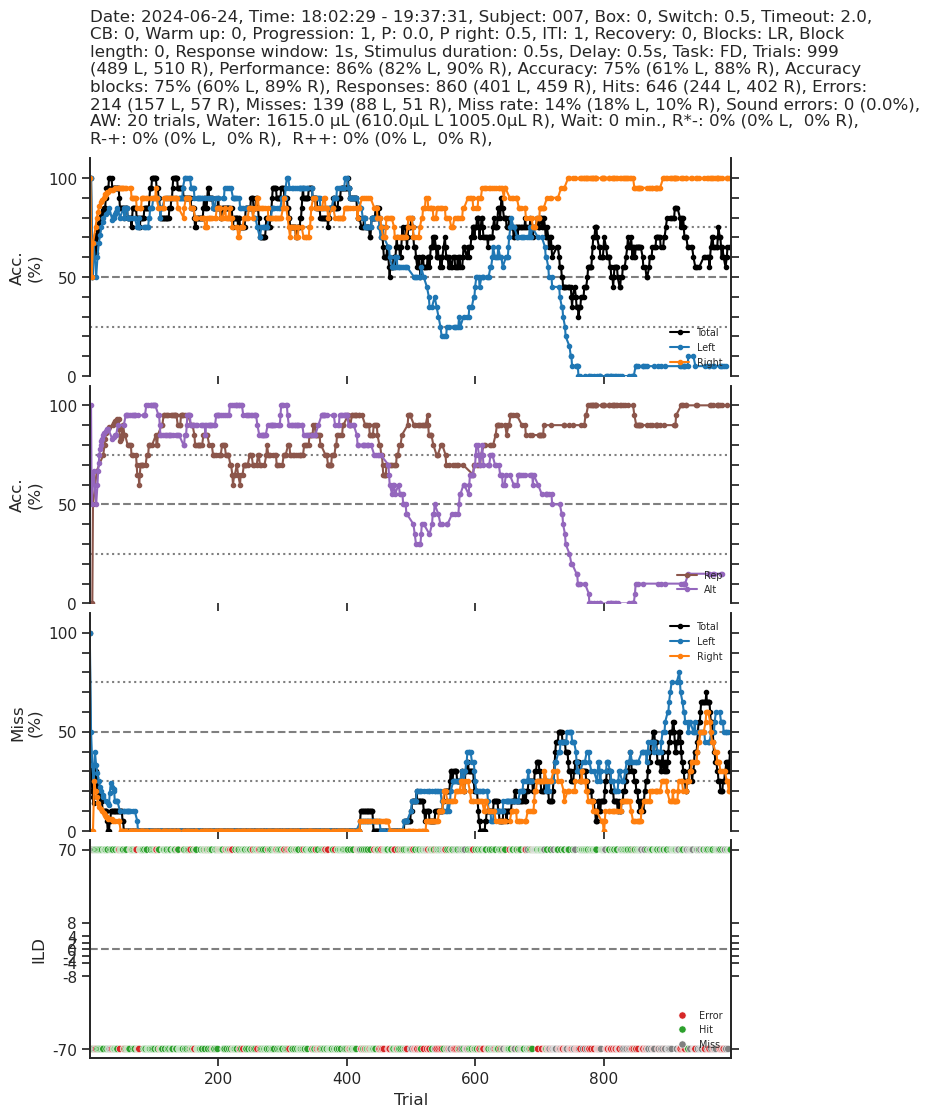

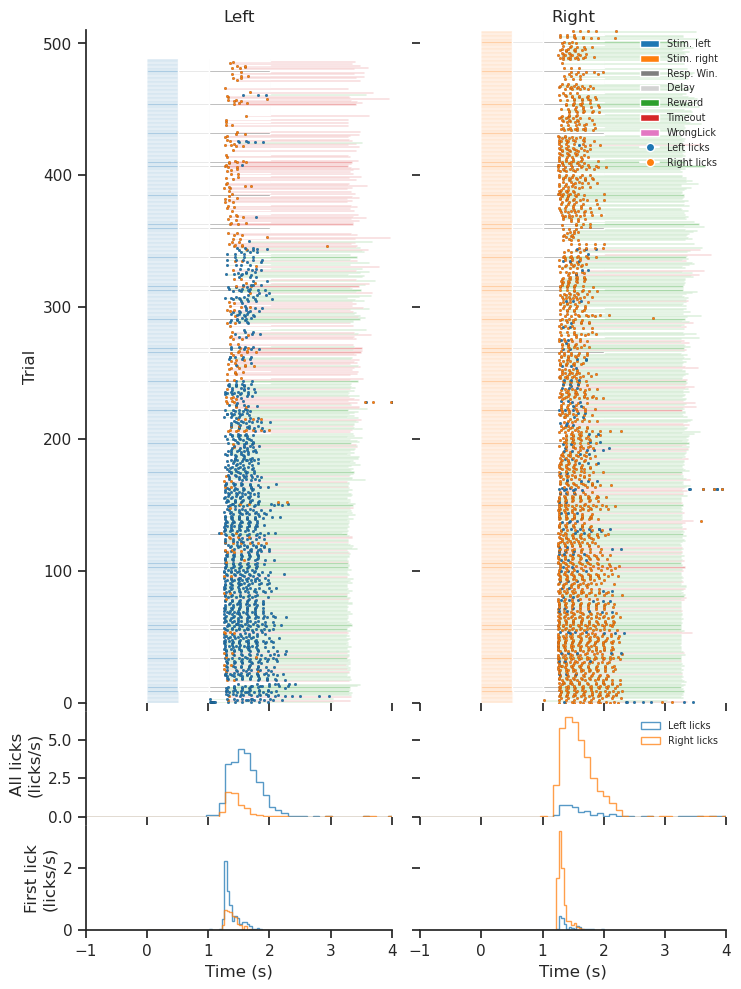

In [14]:
from daily_report.daily_report_v6 import *
path_behavior = get_behavior_id('007_2024-06-24_17-47-22')
daily_report_v6(path_behavior)

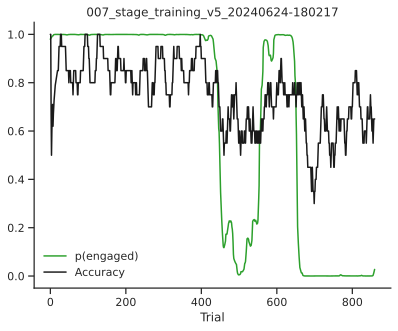

In [5]:
acc = compute_window(df_behavior.Hit[df_behavior.Miss == 0], 20)  # All valid trials
figsize = fig_size(n_cols=1)
figsize = (figsize[0], figsize[1]/2)
plt.plot(df_behavior.p1, color='tab:green', label='p(engaged)')
plt.plot(acc, color='k', label='Accuracy')
plt.xlabel('Trial')
plt.title(df_behavior.Session.unique()[0])
plt.legend(frameon=False)
sns.despine()

In [27]:
def plot_top_selective_units(all_psth, cluster_info, epoch, side=None, group=None, depth=None, n_top=3, save=True):

    # Add selectivity from all clusters before any filtering
    params, pvalues, selective_mask = get_selectivity(bins, all_psth, df_behavior.Side.values, epoch=epoch, n_shuffles=0)
    cluster_info['weights'] = params
    cluster_info['pvalues'] = pvalues
    cluster_info['selective_mask'] = selective_mask

    # Filter units
    if group is not None or depth is not None:
        all_psth, cluster_info = filter_units(bins, all_psth, cluster_info, min_fr=None, max_fano=None, group=group, depth=depth)

    # Keep only selective units
    cluster_info = cluster_info[cluster_info.selective_mask]

    # Keep only left selective units (negative params)
    if side is not None:
        if side == 'left':
            cluster_info = cluster_info[cluster_info.weights < 0]
        elif side == 'right':
            cluster_info = cluster_info[cluster_info.weights > 0]

    # Sort by selectivity (pvalue)
    cluster_info = cluster_info.sort_values(by='pvalues', ascending=True)
    top = cluster_info['cluster_id'][:n_top].tolist()

    for cluster in top:
        df_cluster = df_spikes[df_spikes.cluster == cluster]
        cluster_report(df_cluster, cluster_info, df_ttl, df_behavior, align=align, time_win=time_win, bin_size=bin_size, save=False)
        if save:
            plt.savefig((Path.home() / 'PycharmProjects' / 'ephys' / 'analysis' / 'notebook_files') / epoch / group / side / f'cluster_{cluster}.pdf', format='pdf')
            plt.savefig((Path.home() / 'PycharmProjects' / 'ephys' / 'analysis' / 'notebook_files') / epoch / group / side / f'cluster_{cluster}.svg', format='svg')
            plt.savefig((Path.home() / 'PycharmProjects' / 'ephys' / 'analysis' / 'notebook_files') / epoch / group / side / f'cluster_{cluster}.png', format='png')
            plt.close()

In [30]:
# Paramteres to run cluster report
align = 'stim'
time_win = [-1, 3]
bin_size = 0.1
group = 'mua'
depth = (0, 1.3)

## Stimulus selective

In [33]:
plot_top_selective_units(all_psth, cluster_info, 'stim', side='left', group=group, depth=depth, n_top=5)
plot_top_selective_units(all_psth, cluster_info, 'stim', side='right', group=group, depth=depth, n_top=5)

stim selectivity: 25.7% (176/686 neurons)
Removed 127 units by group
Removed 0 units by depth
559 / 686 units kept
Doing report of cluster 151...


[2026-02-28 00:18:59,014] utils - WARNING: Correcting 250 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


Doing report of cluster 48...


[2026-02-28 00:19:11,125] utils - WARNING: Correcting 67 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


Doing report of cluster 510...


...

[2026-02-28 00:20:36,906] utils - WARNING: Correcting 45 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


Doing report of cluster 620...


[2026-02-28 00:20:53,023] utils - WARNING: Correcting 870 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


Doing report of cluster 835...


[2026-02-28 00:21:11,674] utils - WARNING: Correcting 1215 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


## Delay selective

In [35]:
plot_top_selective_units(all_psth, cluster_info, 'delay', side='left', group=group, depth=depth, n_top=5)
plot_top_selective_units(all_psth, cluster_info, 'delay', side='right', group=group, depth=depth, n_top=5)

delay selectivity: 24.2% (166/686 neurons)
Removed 127 units by group
Removed 0 units by depth
559 / 686 units kept
Doing report of cluster 762...


[2026-02-28 00:24:00,195] utils - WARNING: Correcting 20 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


Doing report of cluster 764...


[2026-02-28 00:24:15,217] utils - WARNING: Correcting 21 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


Doing report of cluster 635...


...

[2026-02-28 00:25:37,685] utils - WARNING: Correcting 44 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


Doing report of cluster 606...


[2026-02-28 00:25:49,339] utils - WARNING: Correcting 45 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


Doing report of cluster 721...


[2026-02-28 00:26:04,466] utils - WARNING: Correcting 747 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


## Response selective

In [36]:
plot_top_selective_units(all_psth, cluster_info, 'resp', side='left', group=group, depth=depth, n_top=5)
plot_top_selective_units(all_psth, cluster_info, 'resp', side='right', group=group, depth=depth, n_top=5)

resp selectivity: 29.0% (199/686 neurons)
Removed 127 units by group
Removed 0 units by depth
559 / 686 units kept
Doing report of cluster 1...


[2026-02-28 00:26:24,231] utils - WARNING: Correcting 406 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


Doing report of cluster 127...


[2026-02-28 00:26:41,478] utils - WARNING: Correcting 184 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


Doing report of cluster 176...


...

[2026-02-28 00:28:04,952] utils - WARNING: Correcting 160 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


Doing report of cluster 545...


[2026-02-28 00:28:17,783] utils - WARNING: Correcting 133 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


Doing report of cluster 68...


[2026-02-28 00:28:30,811] utils - WARNING: Correcting 577 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.


# Save all notebook's figures

In [14]:
# Whole notebook ouputs (no input or prompt, only Markdown and figures)
!jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt  # As HTML
!jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt  # As PDF
os.chdir(Path.home() / 'PycharmProjects' / 'ephys' /'analysis')
save_notebook_files('notebook.ipynb')  # Export all figures

[NbConvertApp] Converting notebook notebook.ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('jetTransient' was unexpected)

Failed validating 'additionalProperties' in display_data:

On instance['cells'][8]['outputs'][1]:
{'data': {'image/png': 'iVBORw0KGgoAAAANSUhEUgAAAUUAAAD2CAYAAABBXZUyAAAAOnRFWHRTb2Z0d2Fy...',
          'text/plain': '<Figure size 313.5x235.125 with 1 Axes>'},
 'jetTransient': {'display_id': None},
 'metadata': {},
 'output_type': 'display_data'}
[NbConvertApp] WARNING | Alternative text is missing on 12 image(s).
[NbConvertApp] Writing 1112569 bytes to notebook.html
[NbConvertApp] Converting notebook notebook.ipynb to pdf
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('jetTransient' was unexpected)

Failed validating 'additionalProperties' in display_data:

On instance['cells'][8]['outputs'][1]:
{'data': {'image/png': 'iVBORw0KGgoAAAANSUhEUgAAAUUAAAD2CAYAAABBXZUyAAAAOnRF